In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

sns.set(style='whitegrid')

In [2]:
df = pd.read_csv('diabetes.csv')

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[cols] = df[cols].replace(0, np.nan)

In [9]:
print("Missing values before:", df[cols].isnull().sum())

Missing values before: Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [10]:
for col in cols:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after:", df[cols].isnull().sum())

Missing values after: Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


In [11]:
print("Shape before removing outliers:", df.shape)

Shape before removing outliers: (768, 9)


In [12]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Shape after removing outliers:", df_clean.shape)

Shape after removing outliers: (375, 9)


In [13]:
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

In [14]:
print("Before Normalization:")
print(X.describe())

Before Normalization:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   375.000000  375.000000     375.000000     375.000000  375.000000   
mean      4.333333  120.125333      73.066667      28.976000  124.984000   
std       3.331639   28.786375      10.268759       4.618257    2.213174   
min       0.000000   44.000000      44.000000      15.000000  114.000000   
25%       2.000000  101.000000      66.000000      29.000000  125.000000   
50%       4.000000  115.000000      72.000000      29.000000  125.000000   
75%       7.000000  137.000000      80.000000      29.000000  125.000000   
max      13.000000  197.000000     104.000000      42.000000  135.000000   

             BMI  DiabetesPedigreeFunction         Age  
count  375.00000                375.000000  375.000000  
mean    31.68240                  0.387872   34.530667  
std      6.22331                  0.240621   11.622332  
min     18.20000                  0.078000   21.000000  
25%     

In [15]:
minmax = MinMaxScaler()
X_minmax = minmax.fit_transform(X)
X_minmax = pd.DataFrame(X_minmax, columns=X.columns)

In [16]:
print("After Min-Max Normalization:")
print(X_minmax.describe())

After Min-Max Normalization:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   375.000000  375.000000     375.000000     375.000000  375.000000   
mean      0.333333    0.497551       0.484444       0.517630    0.523048   
std       0.256280    0.188146       0.171146       0.171047    0.105389   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       0.153846    0.372549       0.366667       0.518519    0.523810   
50%       0.307692    0.464052       0.466667       0.518519    0.523810   
75%       0.538462    0.607843       0.600000       0.518519    0.523810   
max       1.000000    1.000000       1.000000       1.000000    1.000000   

              BMI  DiabetesPedigreeFunction         Age  
count  375.000000                375.000000  375.000000  
mean     0.429376                  0.278412    0.300681  
std      0.198195                  0.216192    0.258274  
min      0.000000                  0.000000    0.00000

In [17]:
zscore = StandardScaler()
X_zscore = zscore.fit_transform(X)
X_zscore = pd.DataFrame(X_zscore, columns=X.columns)

print("After Z-score Normalization:")
print(X_zscore.describe())

After Z-score Normalization:
        Pregnancies       Glucose  BloodPressure  SkinThickness       Insulin  \
count  3.750000e+02  3.750000e+02   3.750000e+02   3.750000e+02  3.750000e+02   
mean   8.052818e-17  1.042129e-16   3.825088e-16   1.894781e-16  2.444267e-15   
std    1.001336e+00  1.001336e+00   1.001336e+00   1.001336e+00  1.001336e+00   
min   -1.302399e+00 -2.648025e+00  -2.834374e+00  -3.030293e+00 -4.969639e+00   
25%   -7.012916e-01 -6.652760e-01  -6.890908e-01   5.203708e-03  7.239095e-03   
50%   -1.001845e-01 -1.782851e-01  -1.040137e-01   5.203708e-03  7.239095e-03   
75%    8.014761e-01  5.869864e-01   6.760891e-01   5.203708e-03  7.239095e-03   
max    2.604797e+00  2.674091e+00   3.016398e+00   2.823879e+00  4.531673e+00   

                BMI  DiabetesPedigreeFunction           Age  
count  3.750000e+02              3.750000e+02  3.750000e+02  
mean   3.552714e-16              9.473903e-18 -1.918465e-16  
std    1.001336e+00              1.001336e+00  1.001336

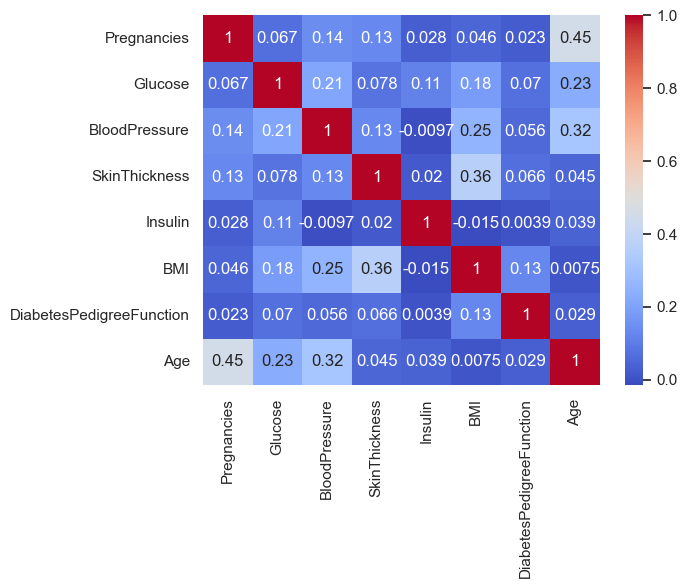

In [18]:
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.show()

In [19]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_zscore)

print("Explained Variance:", pca.explained_variance_ratio_)

Explained Variance: [0.24122067 0.16460947]
